In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [94]:
data = pd.read_csv('housing.csv')

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [96]:
data.dropna(inplace=True)

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [98]:
from sklearn.model_selection import train_test_split  
x = data.drop('median_house_value', axis=1)
y = data['median_house_value']  

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [100]:
train_data = x_train.join(y_train)

In [101]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
1675,-122.26,38.03,41.0,1631.0,282.0,752.0,288.0,3.9345,NEAR BAY,150200.0
3054,-119.34,35.60,33.0,2143.0,488.0,1732.0,509.0,1.9362,INLAND,59000.0
15682,-122.43,37.80,52.0,2696.0,572.0,925.0,552.0,5.0365,NEAR BAY,500000.0
19277,-122.73,38.43,29.0,2677.0,691.0,1880.0,664.0,2.1864,<1H OCEAN,143200.0
13757,-117.14,34.01,26.0,7561.0,1051.0,2909.0,1012.0,7.2972,INLAND,269600.0
...,...,...,...,...,...,...,...,...,...,...
7315,-118.19,33.97,34.0,2700.0,763.0,2815.0,767.0,2.4196,<1H OCEAN,178400.0
20569,-121.76,38.66,17.0,5320.0,984.0,2866.0,928.0,4.1997,INLAND,133400.0
3266,-122.89,39.11,10.0,1588.0,333.0,585.0,254.0,2.2551,INLAND,71100.0
6910,-117.95,33.95,29.0,4943.0,674.0,1913.0,641.0,6.8189,<1H OCEAN,379300.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

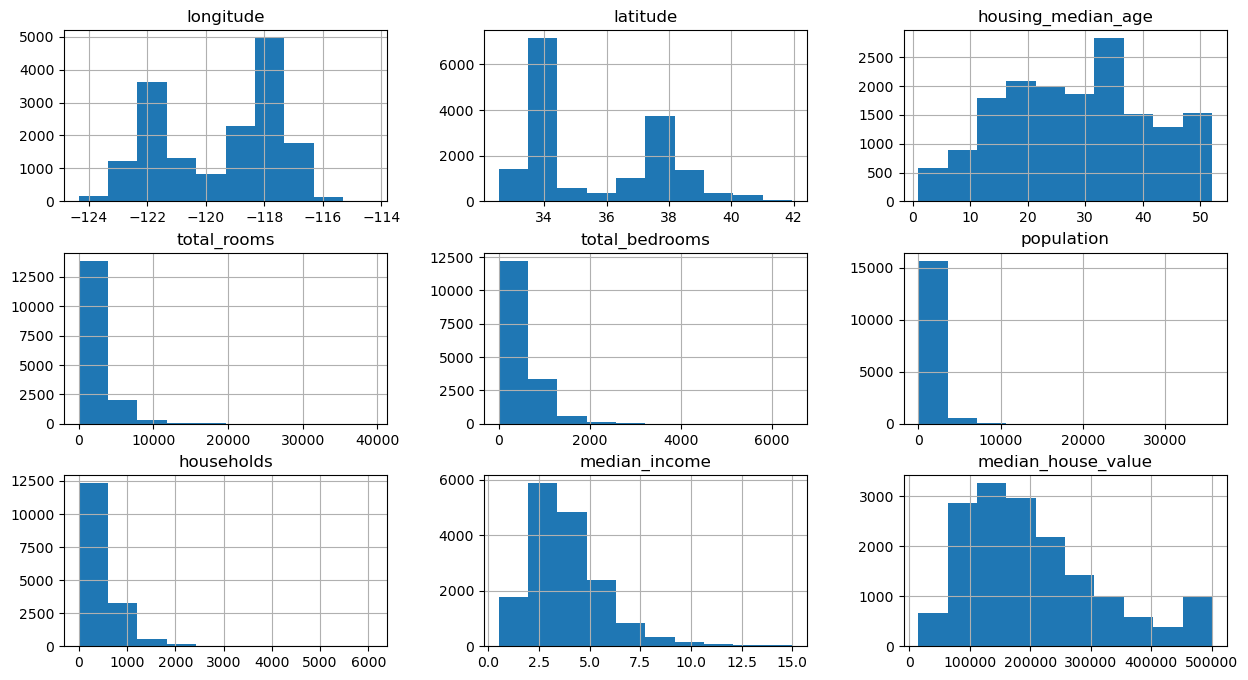

In [102]:
train_data.hist(figsize=(15, 8))

<Axes: >

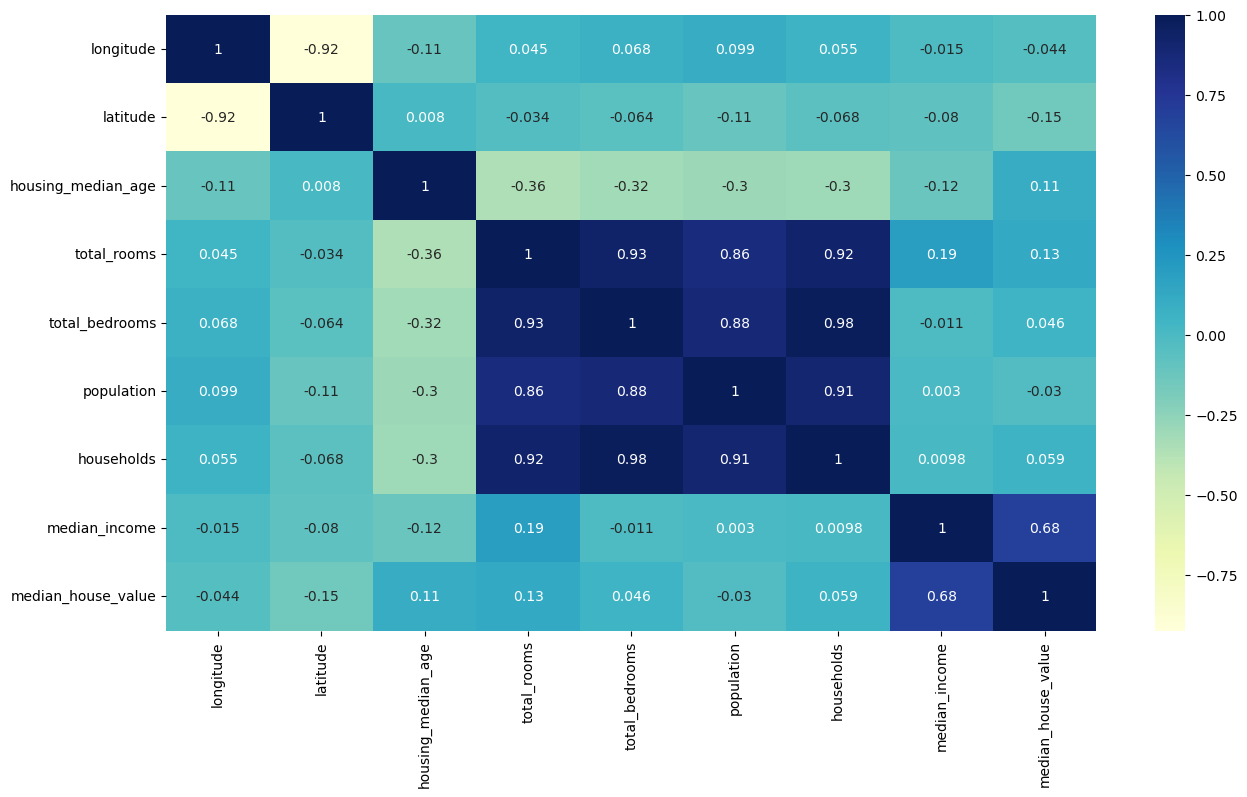

In [103]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu')

In [104]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

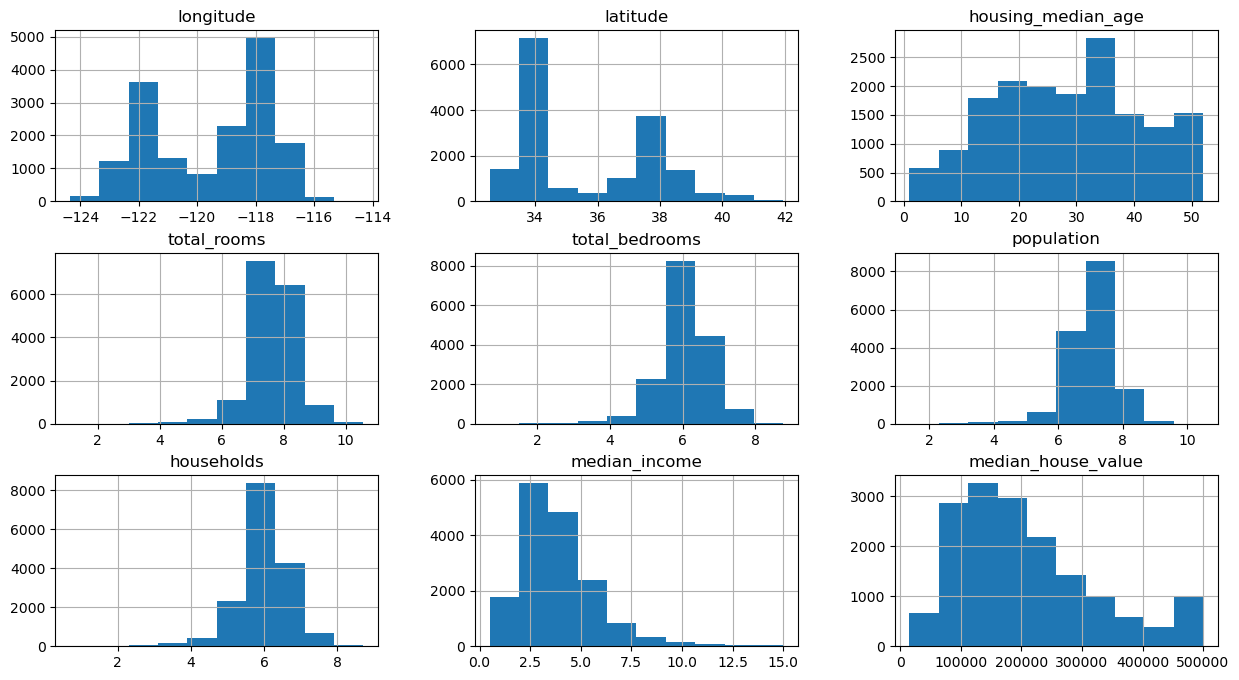

In [105]:
train_data.hist(figsize=(15, 8))

In [106]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7245
INLAND        5178
NEAR OCEAN    2111
NEAR BAY      1808
ISLAND           4
Name: count, dtype: int64

In [107]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop('ocean_proximity', axis=1)

In [108]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
1675,-122.26,38.03,41.0,7.397562,5.645447,6.624065,5.666427,3.9345,150200.0,False,False,False,True,False
3054,-119.34,35.60,33.0,7.670429,6.192362,7.457609,6.234411,1.9362,59000.0,False,True,False,False,False
15682,-122.43,37.80,52.0,7.899895,6.350886,6.830874,6.315358,5.0365,500000.0,False,False,False,True,False
19277,-122.73,38.43,29.0,7.892826,6.539586,7.539559,6.499787,2.1864,143200.0,True,False,False,False,False
13757,-117.14,34.01,26.0,8.930891,6.958448,7.975908,6.920672,7.2972,269600.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7315,-118.19,33.97,34.0,7.901377,6.638568,7.943073,6.643790,2.4196,178400.0,True,False,False,False,False
20569,-121.76,38.66,17.0,8.579417,6.892642,7.961021,6.834109,4.1997,133400.0,False,True,False,False,False
3266,-122.89,39.11,10.0,7.370860,5.811141,6.373320,5.541264,2.2551,71100.0,False,True,False,False,False
6910,-117.95,33.95,29.0,8.505930,6.514713,7.556951,6.464588,6.8189,379300.0,True,False,False,False,False


<Axes: >

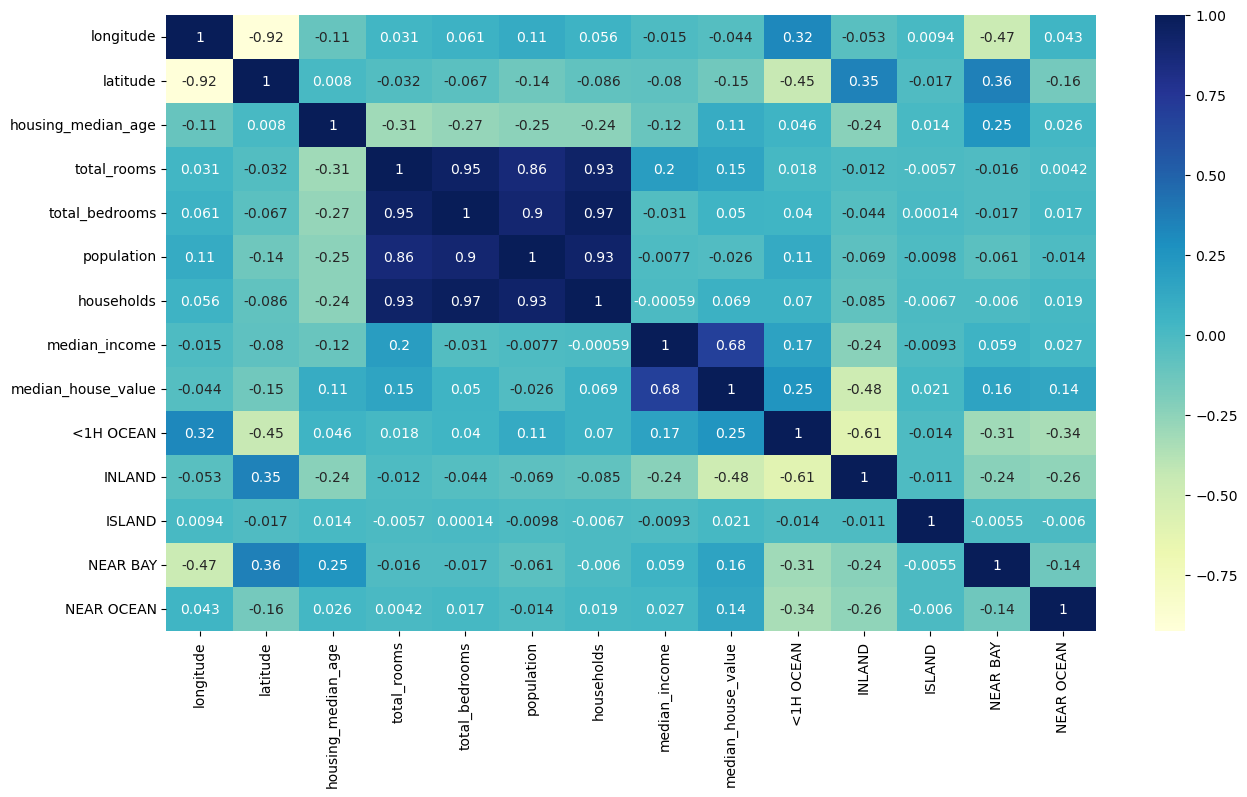

In [109]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

<Axes: xlabel='latitude', ylabel='longitude'>

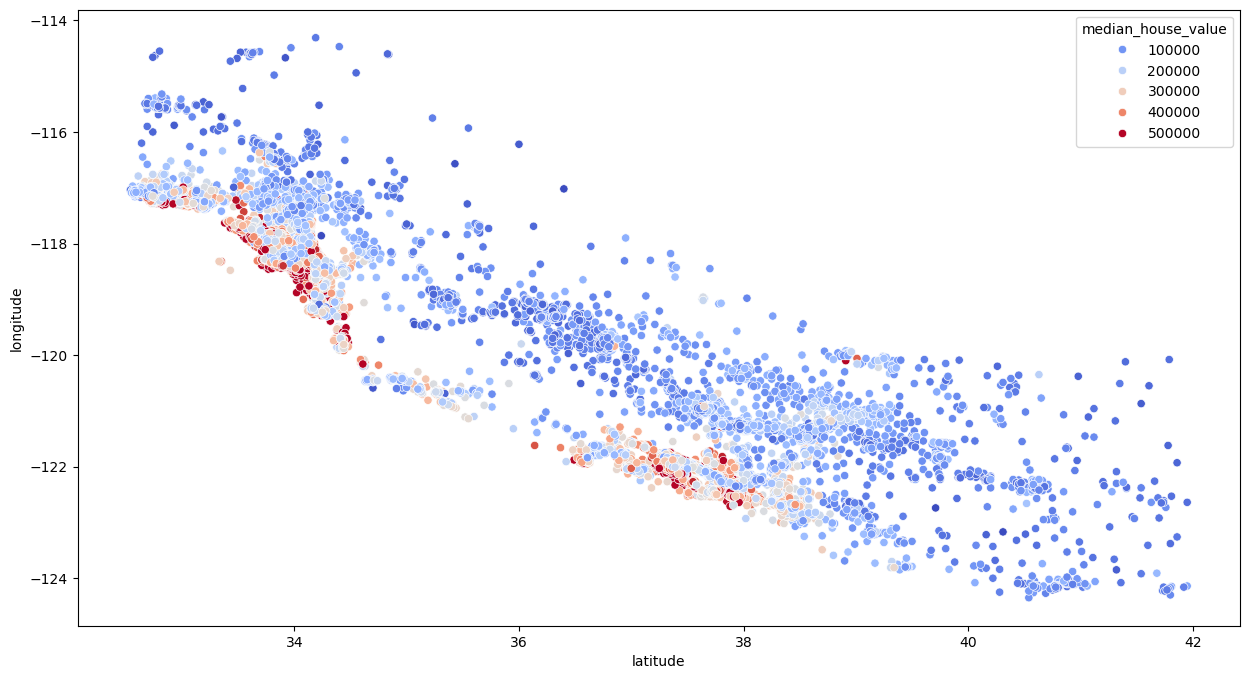

In [110]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='latitude', y='longitude', data=train_data,hue='median_house_value', palette='coolwarm')

In [111]:
train_data['bedroom_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms']/train_data['households']

<Axes: >

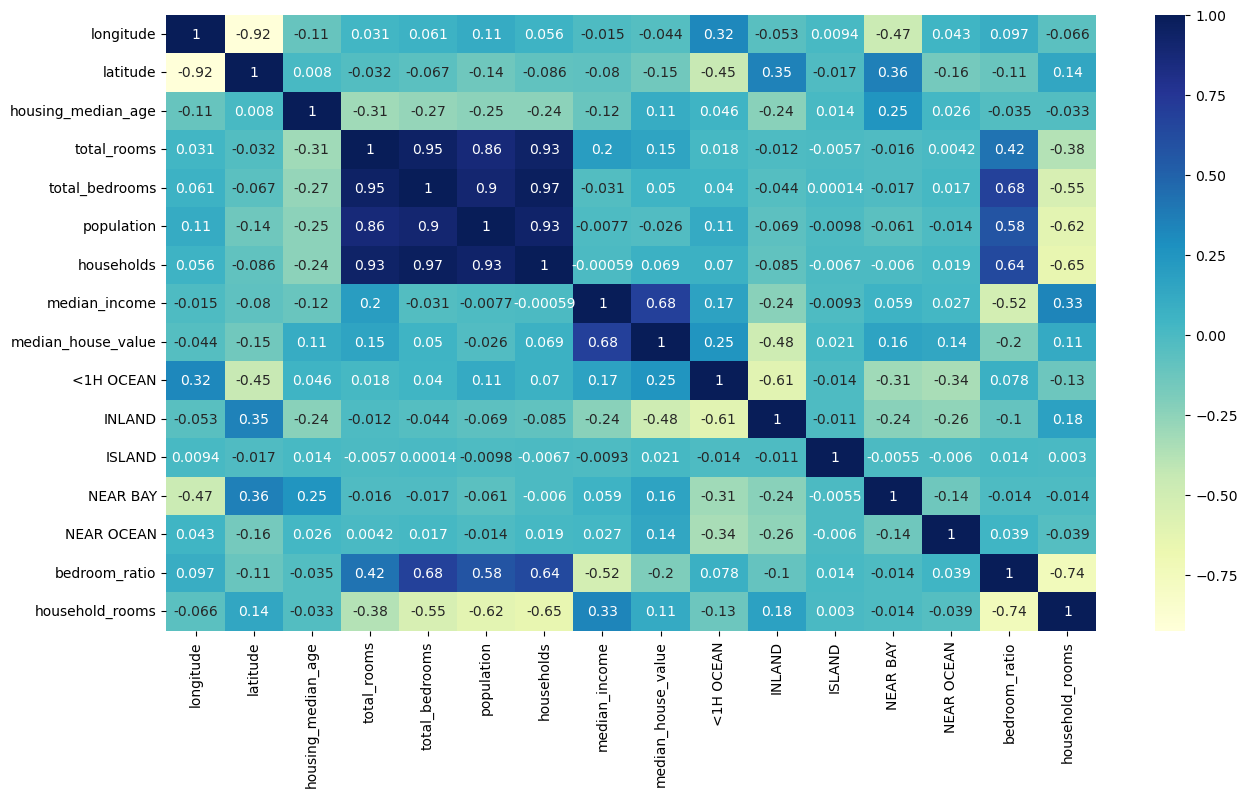

In [112]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

In [113]:
from sklearn.linear_model import LinearRegression
x_train,y_train = train_data.drop('median_house_value', axis=1), train_data['median_house_value']
reg = LinearRegression()
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [114]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop('ocean_proximity', axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms']/test_data['households']

In [115]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
4033,-118.55,34.17,36.0,7.662938,5.697093,6.635947,5.616771,7.8392,500001.0,True,False,False,False,False,0.743461,1.364296
18726,-122.30,40.58,19.0,6.950815,5.323010,6.226537,5.214936,1.6033,98800.0,False,True,False,False,False,0.765811,1.332867
13144,-121.56,38.26,43.0,7.553287,5.793014,6.904751,5.752573,2.9744,136800.0,False,True,False,False,False,0.766953,1.313028
11097,-117.88,33.83,22.0,8.167068,6.298949,7.442493,6.263398,6.4685,241200.0,True,False,False,False,False,0.771262,1.303936
2130,-119.71,36.80,17.0,7.629004,5.905362,7.138867,5.908083,3.9338,84700.0,False,True,False,False,False,0.774067,1.291282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,-122.27,37.85,52.0,8.313117,6.825460,7.496097,6.704414,2.7054,182300.0,False,False,False,True,False,0.821047,1.239947
13138,-121.44,38.46,10.0,8.399985,6.800170,7.824046,6.785588,3.5461,103600.0,False,True,False,False,False,0.809546,1.237916
8576,-118.42,33.90,43.0,7.240650,5.774552,6.315358,5.693732,5.9596,500001.0,True,False,False,False,False,0.797518,1.271688
9351,-122.55,37.97,52.0,7.711101,5.676754,6.595781,5.537334,7.1155,500001.0,False,False,False,True,False,0.736179,1.392566


In [116]:
x_test,y_test = test_data.drop('median_house_value', axis=1), test_data['median_house_value']

In [117]:
reg.score(x_test, y_test)

0.6915134821588873